In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

model_c = XGBClassifier()
model_c.load_model('../models/xgboost_skip_model.json')

X_shap_sample = pd.read_parquet('../data/processed/shap_sample.parquet')
print(X_shap_sample.shape)
print(X_shap_sample.columns.tolist())

(50000, 10)
['session_position', 'session_progress', 'prev_is_skip', 'rolling_skip_rate_5', 'artist_repeat', 'genre_changed', 'hour_sin', 'hour_cos', 'day_of_week', 'user_historical_skip_rate']


In [2]:
import os
print(os.getcwd())
!dir ..\models

D:\skip-behavior-analysis\notebooks
 Volume in drive D is DATA
 Volume Serial Number is 308E-B66D

 Directory of D:\skip-behavior-analysis\models

01-09-2026  10:53 AM    <DIR>          .
01-09-2026  11:02 AM    <DIR>          ..
01-09-2026  10:53 AM         1,428,981 xgboost_skip_model.json
               1 File(s)      1,428,981 bytes
               2 Dir(s)  932,092,420,096 bytes free


In [3]:
import os
print(os.getcwd())

D:\skip-behavior-analysis


In [3]:
!pip install shap

   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 9.1 MB/s  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.8/41.9 MB 12.6 MB/s eta 0:00:04
   ---- ----------------------------------- 4.2/41.9 MB 11.4 MB/s eta 0:00:04
   ----- ---------------------------------- 6.0/41.9 MB 10.5 MB/s eta 0:00:04
   ------- -------------------------------- 8.1/41.9 MB 9.7 MB/s eta 0:00:04
   --------- ------------------------------ 10.2/41.9 MB 9.8 MB/s eta 0:00:04
   ------------ --------------------------- 12.8/41.9 MB 10.2 MB/s eta 0:00:03
   -------------- ------------------------- 15.5/41.9 MB 10.5 MB/s eta 0:00:03
   ----------------- ---------------------- 18.4/41.9 MB 10.8 MB/s eta 0:00:03
   ------------------- -------------------- 20.4/41.9 MB 10.9 MB/s eta 0:00:02
   ---------------------- ----------------- 23.3/41.9 MB 11.0 MB/s eta 0:00:0


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import shap

# TreeExplainer is optimized specifically for tree-based models like XGBoost —
# much faster than the general-purpose SHAP explainer
explainer = shap.TreeExplainer(model_c)
shap_values = explainer.shap_values(X_shap_sample)

print(shap_values.shape)  # should be (50000, 10) — one SHAP value per feature per row

(50000, 10)


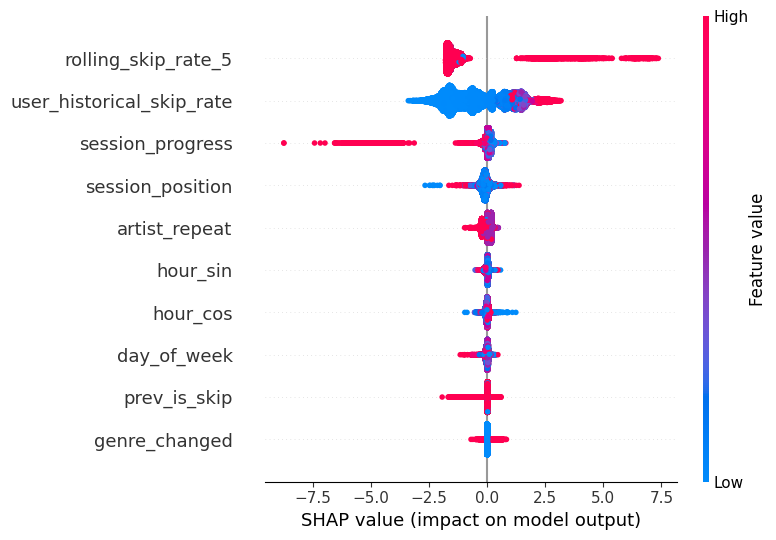

In [5]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.tight_layout()
plt.savefig('outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

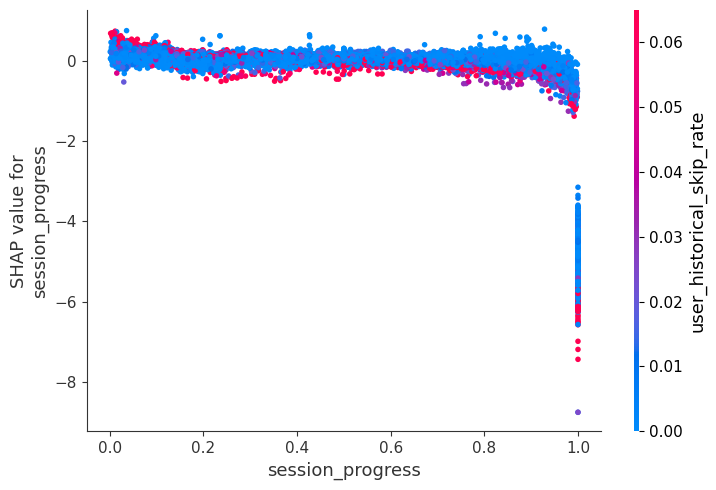

In [6]:
shap.dependence_plot('session_progress', shap_values, X_shap_sample, show=False)
plt.tight_layout()
plt.savefig('outputs/shap_dependence_session_progress.png', dpi=150, bbox_inches='tight')
plt.show()

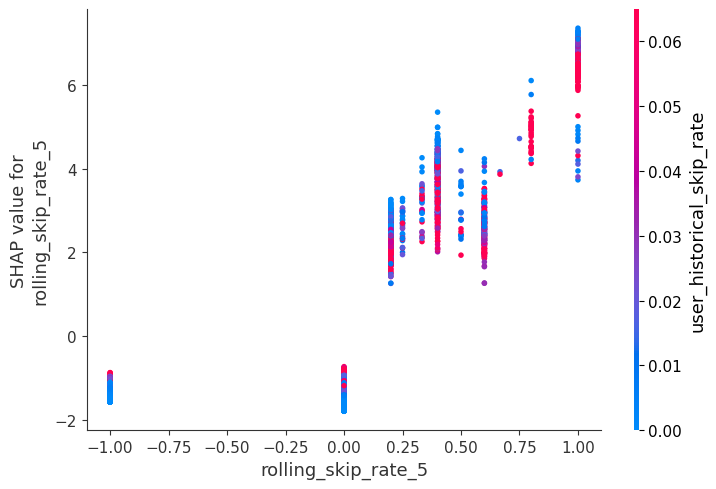

In [7]:
shap.dependence_plot('rolling_skip_rate_5', shap_values, X_shap_sample, show=False)
plt.tight_layout()
plt.savefig('outputs/shap_dependence_rolling_skip_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
!type ..\requirements.txt

pandas>=2.0
duckdb>=0.10
rapidfuzz>=3.0
scikit-learn>=1.4
xgboost>=2.0
shap>=0.45
matplotlib>=3.8
seaborn>=0.13
jupyter>=1.0
